# Embeddings and Latent Space

## Give a catalogue a useful map

Imagine a catalogue containing apple, pear, car, bus, rose, and tulip. Assigning IDs zero through five makes lookup easy, but subtraction between IDs has no useful meaning: bus is not three units more than apple. One-hot vectors avoid this false ordering, but every distinct pair is equally far apart and their width grows with the catalogue.

An **embedding** gives each category a short, learnable vector. A training task determines which relationships become useful. In this lesson we explicitly supply fruit, vehicle, and flower groups. The model learns to reflect those labels; it does not discover word meanings by reading language.

Read these notes first, then run the companion from top to bottom. Everything uses small, locally generated data and runs on CPU.

## Start with the problem this lesson solves

A category ID identifies an item but does not describe similarity. If apple, pear, and car have IDs zero, one, and two, arithmetic on those IDs does not tell us that apple and pear should be related. An embedding learns a vector for each category so a downstream task can use meaningful numerical relationships.

A feature-based encoder solves a related problem: compute a useful internal representation for an input, including a new input whose features are available. Both are ways an ANN can represent information; a lookup stores vectors, while an encoder calculates them.

## Follow lookup, comparison, learning, and compression

**Look up a category.** Let the embedding table's rows be apple $[1,0]$, pear $[0.8,0.6]$, and car $[-1,0]$. Pear's ID one selects the second row. Multiplying one-hot vector $[0,1,0]$ by the table does the same thing: $0[1,0]+1[0.8,0.6]+0[-1,0]=[0.8,0.6]$. The ID is an address, not a continuous measurement.

**Compare two vectors.** Apple and pear have dot product $1(0.8)+0(0.6)=0.8$. Their lengths are $\sqrt{1^2+0^2}=1$ and $\sqrt{0.8^2+0.6^2}=1$. Cosine similarity is dot product divided by the product of lengths, so it is $0.8$. Pear and car have cosine $-0.8$. Among those two candidates, apple is therefore pear's nearest neighbor by cosine. These are chosen vectors; useful relationships must come from training data in a learned system.

**Change a selected row.** To expose learning, temporarily give pear target vector $t=[1,0]$ and loss $L=\tfrac12\|E_1-t\|^2$. Error is $[-0.2,0.6]$. Squared errors are $[0.04,0.36]$, so $L=\tfrac12(0.4)=0.2$. The gradient is $E_1-t=[-0.2,0.6]$.

At SGD rate $0.1$, the new pear row is $[0.8,0.6]-0.1[-0.2,0.6]=[0.82,0.54]$. New error is $[-0.18,0.54]$, and new loss is $\tfrac12(0.0324+0.2916)=0.162$. The other two rows receive zero gradient from this single lookup. A downstream task would normally supply the learning signal instead of this hand-written vector target.

**Compute a representation rather than retrieving it.** Here is a separate, exactly solvable linear encoder–decoder miniature. Suppose clean sensors report $x=[u,v,u+v,u-v]$. For hidden factors $u=2,v=1$, readings are $[2,1,3,1]$. An encoder that selects the first two readings computes $z=[2,1]$. A decoder computes $[z_1,z_2,z_1+z_2,z_1-z_2]=[2,1,3,1]$. All four reconstruction errors are zero, so MSE is zero.

Four recorded numbers needed only two independent values in this constructed process. The real companion learns a linear bottleneck from noisy, standardized data; it is not given this hand-built encoder and should not be expected to reconstruct noise perfectly.

## Why a learned representation helps

A useful embedding lets a model compare categories and reuse relationships instead of treating every ID as unrelated. A bottleneck can preserve important structure while reducing the number of values passed onward. Reconstruction error teaches the encoder which information the decoder needs.

Similarity depends on the training objective; an embedding does not inherently know the meaning of a word. A lookup has no learned row for an unseen ID. An encoder can process new feature vectors, but usefulness still depends on how representative training was. A linear autoencoder is closely related to PCA, so reconstruction success alone does not establish a neural-network advantage over that simpler method.

## Select a row instead of treating an ID as a measurement

Let the embedding table be

$$E=\begin{bmatrix}1&0\\0.8&0.6\\-1&0\end{bmatrix}.$$

Its rows represent apple, pear, and car. There are $V=3$ categories and $d=2$ coordinates, so its shape is $(3,2)$ and it has six trainable parameters. Looking up pear, whose ID is one, returns $E_1=[0.8,0.6]$.

The one-hot vector for pear is $e_1=[0,1,0]$. Multiplication selects the same row:

$$e_1E=0[1,0]+1[0.8,0.6]+0[-1,0]=[0.8,0.6].$$

For a batch of four IDs, lookup returns shape $(4,2)$. An embedding can feed a classifier, recommender, or sequence model just like other input features. The catalogue-to-ID mapping must be saved with the weights.

Lookup avoids constructing a large one-hot input. With default `nn.Embedding`, the weight gradient is still a **dense tensor**, with zero rows for categories unused by the lookup loss. `sparse=True` requests sparse gradients and requires a compatible optimizer; it does not make the embedding weight table itself sparse.

## Compare directions with an actual calculation

For apple $a=[1,0]$ and pear $p=[0.8,0.6]$,

$$a\cdot p=0.8,\quad \|a\|=1,\quad \|p\|=\sqrt{0.64+0.36}=1,$$

so cosine similarity is $0.8/(1\times1)=0.8$. Apple and car have cosine similarity $-1$. The range is from $-1$ (opposite directions), through zero (perpendicular), to one (same direction).

Cosine compares direction. Euclidean distance compares location, and a dot product includes both direction and magnitude. Doubling pear's vector doubles its dot product with apple, but leaves cosine unchanged. Consequently, a cosine objective need not bring raw vector positions close together.

Cosine is undefined for a zero vector. Numerical implementations clamp the denominator with a small epsilon to avoid division by zero; the resulting zero-vector score has no meaningful direction interpretation. For retrieval, normalize nonzero vectors once and use dot products to obtain cosine scores.

## Follow the loss back to a selected row

Suppose pear's current vector is $[0.8,0.6]$ and a teaching target is $[1,0]$. Use the illustrative loss

$$L=\tfrac12\|E_1-[1,0]\|^2=0.2.$$

The gradient for that row is $[-0.2,0.6]$. With SGD and learning rate $0.1$, the new row is

$$[0.8,0.6]-0.1[-0.2,0.6]=[0.82,0.54].$$

The other rows receive zero lookup gradients in this example. Repeated occurrences of an ID accumulate contributions to the same row. In a full model, the downstream task supplies this gradient rather than a hand-written coordinate target. Weight decay or optimizer momentum can also change rows with zero current gradients, so the unchanged-row demonstration deliberately uses plain SGD without either.

## Teach relationships instead of choosing coordinates

The companion initializes six two-dimensional vectors randomly. It builds all unordered pairs: three same-group pairs and twelve different-group pairs. We train with

$$L=\operatorname{mean}_{same}(1-s_{ij})+\operatorname{mean}_{different}\max(0,s_{ij}-m),\qquad m=-0.2,$$

where $s_{ij}$ is cosine similarity. The first term aligns related items. The second penalizes unrelated pairs whose similarity exceeds the margin. Each group of pairs is averaged separately, so the more numerous negative pairs do not automatically dominate.

A negative margin asks unrelated vectors to point more than ninety degrees apart. This is feasible for our three groups in two dimensions, but demanding the same separation for many groups may be impossible. This is a small supervised metric-learning demonstration, not a general-purpose language embedding recipe.

The companion records the loss, compares initial and final cosine scores, and plots **normalized** vectors with matching axes. It recomputes final scores after the last optimizer update so reported numbers and plotted weights agree.

## Use the geometry to retrieve a neighbor

To find a neighbor for apple, compare its normalized vector with every other normalized row, exclude apple itself, and select the highest dot product. The companion prints this result for every item and checks whether the neighbor belongs to the same supplied group.

This check measures whether the toy training objective was learned on the six training categories. It is not held-out evidence of semantic understanding or performance on unseen words. In a real retrieval task, evaluate relevant results on separate queries and candidates.

## Move from a lookup table to an encoder

An embedding table stores a vector for each known ID. An **encoder** computes a vector from an input's features. Both can provide internal representations, but an encoder can process a new feature vector without allocating a new category row.

A **latent space** is the space of these internal, unobserved coordinates. It need not be lower-dimensional, but a bottleneck is one useful example. Our second experiment compresses four sensor measurements to two values and reconstructs the four measurements with a decoder. This introduces the idea of an autoencoder; later lessons can explore nonlinear and probabilistic versions.

We generate four measurements from two hidden factors $u,v$:

$$x=[u,\ v,\ u+v,\ u-v]+\text{small noise}.$$

The model sees only $x$. The generating factors are used only to color the final visualization. A linear encoder maps $(batch,4)$ to $(batch,2)$; a linear decoder maps back to $(batch,4)$. Reconstruction MSE teaches the bottleneck to preserve useful information.

## Distinguish a stored embedding from a computed representation

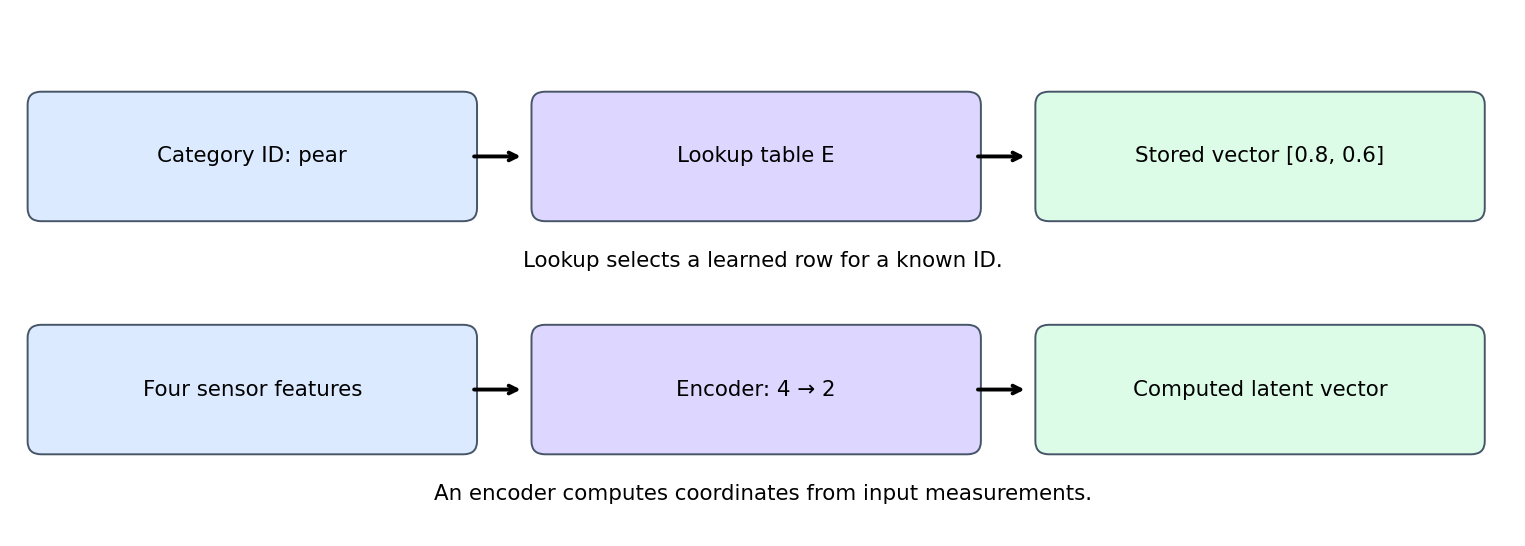

A lookup selects a stored category vector; an encoder computes a vector from features. A decoder can use the computed vector to reconstruct the input.

## Judge the bottleneck on separate examples

The companion generates independent training, validation, and test samples, standardizes each using training statistics, and selects an encoder–decoder snapshot using validation reconstruction MSE. Only then does it evaluate the test set once.

The baseline always predicts the training mean. Beating this baseline demonstrates that the bottleneck preserves information about unseen samples from this synthetic distribution. It does not establish superiority to PCA: a linear autoencoder and PCA learn closely related low-dimensional subspaces under squared-error reconstruction.

The learned coordinates need not equal $u$ and $v$. Rotating or rescaling latent coordinates while compensating in the decoder can preserve the same reconstruction. The scatterplot colors show a relationship, not a fixed interpretation for either axis. Here the latent space really is two-dimensional; projecting a larger embedding down to two dimensions can additionally distort neighborhoods.

## Choose dimensions and handle unfamiliar inputs

- **Dimension:** smaller vectors reduce storage and may constrain overfitting; larger vectors offer more capacity. Choose using task validation, data size, and memory constraints rather than assuming larger is better.
- **Unknown categories:** a lookup table cannot directly index a new ID. An unknown-category row must be included and trained, or a feature-based encoder or subword scheme must supply a representation. An untrained fallback vector has no learned meaning.
- **Data and objective:** frequent categories receive more evidence; rare categories can have weak vectors. Similarity reflects labels, sampling, and biases in the training data.
- **Stability:** random seeds make the demonstration reproducible, but equivalent maps can have different coordinates. Compare useful relationships and downstream quality rather than individual coordinates.
- **Use:** embeddings support retrieval and categorical prediction; latent representations support compression and downstream tasks. Good reconstruction alone does not guarantee a representation is useful for every prediction task.

The companion saves visible outputs and checks the lookup arithmetic, selected-row gradient, cosine behavior, trained neighborhood structure, and held-out reconstruction against the baseline.

## See the learned category directions

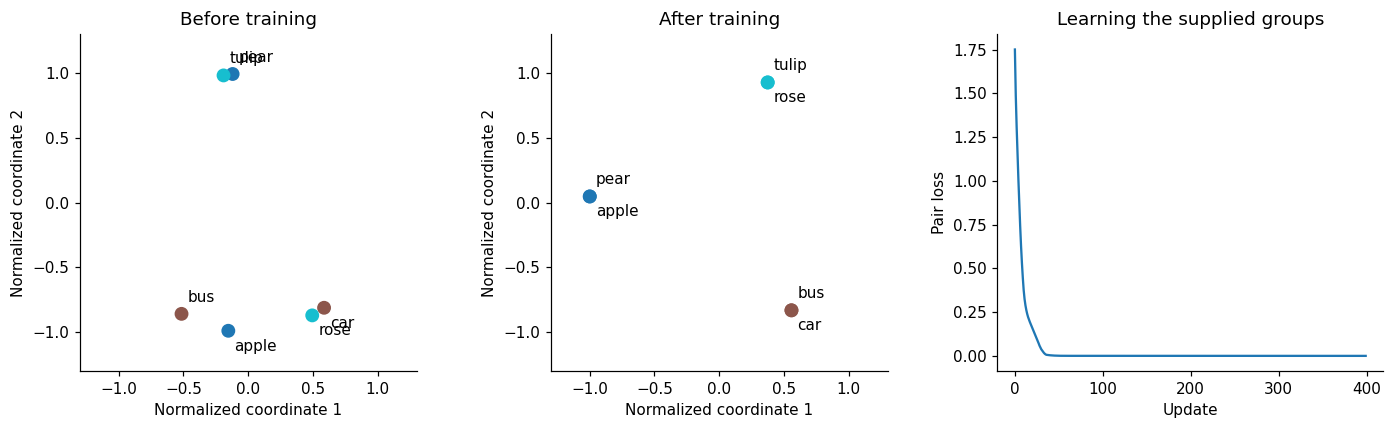

Initial and trained normalized embeddings, with the pair loss. The supplied groups determine which directions align; vector lengths are not constrained by cosine.

## Inspect the learned bottleneck

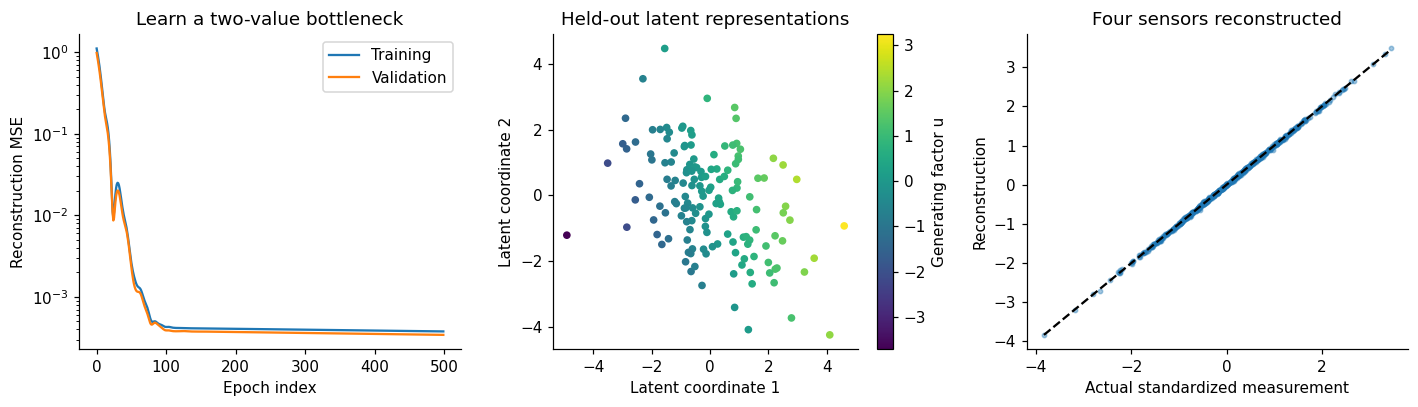

Training and validation reconstruction curves, held-out latent coordinates colored by generating factor u, and actual versus reconstructed standardized measurements.